# Synthetic Data Generation for RAG Evaluation

Session 1 built a vector RAG application over a cat health guideline PDF. This
session creates an evaluation dataset for that application and uses the dataset
to compare two retrieval configurations. All generation, embedding, RAG, and
judge requests are routed through Vercel AI Gateway.

The workflow is:

~~~text
corpus -> knowledge graph -> synthetic examples -> human review
       -> LangSmith dataset -> baseline and candidate experiments
~~~

Synthetic examples reduce the cost of getting started, but generated references
are not automatically ground truth. We will inspect and curate them before using
them as evaluation targets.

> This is an educational cat health exercise, not veterinary advice. Generated
> questions and answers must not be used to diagnose, prescribe, or replace a
> veterinarian.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how Ragas builds a knowledge graph for test data generation.
- Distinguish single-hop specific, multi-hop specific, and multi-hop abstract queries.
- Generate and review synthetic questions, reference contexts, and reference answers.
- Route generation, embeddings, RAG, and judge calls through Vercel AI Gateway.
- Upload reviewed examples to a LangSmith dataset.
- Evaluate answer correctness, answer groundedness, and retrieval relevance.
- Run a controlled RAG experiment that changes one variable at a time.

## Table of Contents

- **Breakout Room #1: Synthetic Test Data with Ragas**
  - Task 1: Environment Setup
  - Task 2: Load the Cat Health Corpus
  - Task 3: Build and Enrich a Knowledge Graph
  - Task 4: Inspect the Query Distribution
  - Task 5: Generate and Inspect a Synthetic Test Set
  - Activity #1: Review and Curate the Dataset
- **Breakout Room #2: RAG Evaluation with LangSmith**
  - Task 6: Create a LangSmith Dataset
  - Task 7: Build a Baseline RAG Application
  - Task 8: Define RAG Evaluators
  - Task 9: Run the Baseline Experiment
  - Task 10: Change One Retrieval Variable and Re-Evaluate
  - Activity #2: Compare, Diagnose, and Iterate
  - Advanced Build: Add Robustness and Adversarial Cases

---
# Breakout Room #1
## Synthetic Test Data with Ragas

Ragas uses the source corpus to create a richer representation of its topics and
relationships. Query synthesizers then select scenarios from that representation
and generate questions plus reference answers.

The knowledge graph is a generation aid. It is not the graph used by the RAG
application in Breakout Room #2.

## Task 1: Environment Setup

From the <code>05_Synthetic_Data_Generation_for_RAG_Evals</code> folder:

~~~bash
uv sync
~~~

Then select the environment created by uv as this notebook's kernel.

Required accounts:

- Vercel AI Gateway for generation, embeddings, the RAG answer model, and judges
- LangSmith for the dataset and experiments

A direct OpenAI API key is not required. The OpenAI SDK is used only as a
protocol-compatible client pointed at Vercel AI Gateway.

The default synthetic test set is intentionally small. Ragas generation and
LLM-as-judge evaluation both make multiple model calls, so start small and scale
only after inspecting quality.

### Imports

In [1]:
from __future__ import annotations

import os
from collections import Counter
from getpass import getpass
from importlib.metadata import version
from pathlib import Path
from uuid import uuid4

import instructor
from IPython.display import display
from openai import OpenAI
from pydantic import BaseModel, field_validator

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langsmith import Client, evaluate
from openevals.llm import create_llm_as_judge
from openevals.prompts import (
    CORRECTNESS_PROMPT,
    RAG_GROUNDEDNESS_PROMPT,
    RAG_RETRIEVAL_RELEVANCE_PROMPT,
)

from ragas.embeddings import embedding_factory
from ragas.llms import llm_factory
from ragas.run_config import RunConfig
from ragas.testset import TestsetGenerator
from ragas.testset.graph import KnowledgeGraph, Node, NodeType
from ragas.testset.synthesizers import (
    MultiHopAbstractQuerySynthesizer,
    MultiHopSpecificQuerySynthesizer,
    SingleHopSpecificQuerySynthesizer,
    default_query_distribution,
)
from ragas.testset.transforms import (
    CustomNodeFilter,
    SummaryExtractor,
    apply_transforms,
    default_transforms_for_prechunked,
)

/Users/paulina/Projects/AIE10/05_Synthetic_Data_Generation_for_RAG_Evals/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### API Keys, Models, and Cost Controls

The notebook reads model names and budgets from environment variables so you can
tune cost without editing every cell. Vercel AI Gateway exposes an
OpenAI-compatible endpoint, so the OpenAI and LangChain clients only need a
different API key, base URL, and provider-qualified model ID.

See the [Vercel AI Gateway Python documentation](https://vercel.com/docs/ai-gateway/sdks-and-apis/python)
for the current authentication and endpoint details.

LangSmith uses <code>LANGSMITH_TRACING</code>. The older
<code>LANGCHAIN_TRACING_V2</code> name from the source notebook is no longer
needed here.

If your LangSmith account is on the EU instance, set
<code>LANGSMITH_ENDPOINT</code> to <code>https://eu.api.smith.langchain.com</code>.
The default US host returns a 403 Forbidden for EU keys, which shows up as
repeated "Failed to multipart ingest runs" warnings while the rest of the
notebook keeps running. The cell below defaults to the EU host; remove or
override that line if your workspace is on the US instance.

In [2]:
gateway_api_key = (
    os.environ.get("AI_GATEWAY_API_KEY")
    or os.environ.get("VERCEL_OIDC_TOKEN")
)

if not gateway_api_key:
    gateway_api_key = getpass("Vercel AI Gateway API Key: ")
    os.environ["AI_GATEWAY_API_KEY"] = gateway_api_key

if not os.environ.get("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass("LangSmith API Key: ")

os.environ.setdefault("LANGSMITH_TRACING", "true")
os.environ.setdefault(
    "LANGSMITH_PROJECT",
    "aim-session-5-synthetic-rag-evals",
)
# This LangSmith account lives on the EU instance, so traces and datasets must
# be sent to the EU host. Posting to the default US endpoint returns 403
# Forbidden. Override LANGSMITH_ENDPOINT before any LangSmith client is built.
os.environ.setdefault(
    "LANGSMITH_ENDPOINT",
    "https://eu.api.smith.langchain.com",
)

GATEWAY_BASE_URL = os.environ.get(
    "AI_GATEWAY_BASE_URL",
    "https://ai-gateway.vercel.sh/v1",
)
GENERATOR_MODEL_NAME = os.environ.get(
    "AIM_GENERATOR_MODEL",
    "openai/gpt-5.4-mini",
)
RAG_MODEL_NAME = os.environ.get(
    "AIM_RAG_MODEL",
    "openai/gpt-5.4-mini",
)
JUDGE_MODEL_NAME = os.environ.get(
    "AIM_JUDGE_MODEL",
    "openai/gpt-5.4-mini",
)
EMBEDDING_MODEL_NAME = os.environ.get(
    "AIM_EMBEDDING_MODEL",
    "openai/text-embedding-3-small",
)
TESTSET_SIZE = int(os.environ.get("AIM_TESTSET_SIZE", "6"))
MAX_CONCURRENCY = int(os.environ.get("AIM_MAX_CONCURRENCY", "2"))

gateway_models = {
    "generator": GENERATOR_MODEL_NAME,
    "rag": RAG_MODEL_NAME,
    "judge": JUDGE_MODEL_NAME,
    "embedding": EMBEDDING_MODEL_NAME,
}
for role, model_name in gateway_models.items():
    if "/" not in model_name:
        raise ValueError(
            f"{role} model must use a provider-qualified AI Gateway ID: "
            f"{model_name!r}"
        )

print(f"Ragas: {version('ragas')}")
print(f"LangSmith: {version('langsmith')}")
print(f"AI Gateway: {GATEWAY_BASE_URL}")
print(f"Generator model: {GENERATOR_MODEL_NAME}")
print(f"RAG model: {RAG_MODEL_NAME}")
print(f"Judge model: {JUDGE_MODEL_NAME}")
print(f"Embedding model: {EMBEDDING_MODEL_NAME}")
print(f"Synthetic examples: {TESTSET_SIZE}")
print(f"LangSmith tracing: {os.environ['LANGSMITH_TRACING']}")
print(f"LangSmith endpoint: {os.environ['LANGSMITH_ENDPOINT']}")

Ragas: 0.4.4.dev8+g298b68274
LangSmith: 0.8.16
AI Gateway: https://ai-gateway.vercel.sh/v1
Generator model: openai/gpt-5.4-mini
RAG model: openai/gpt-5.4-mini
Judge model: openai/gpt-5.4-mini
Embedding model: openai/text-embedding-3-small
Synthetic examples: 6
LangSmith tracing: true
LangSmith endpoint: https://eu.api.smith.langchain.com


## Task 2: Load the Cat Health Corpus

The corpus is the bundled 2021 AAHA/AAFP Feline Life Stage Guidelines PDF used
in Session 1. <code>PyPDFLoader</code> extracts one LangChain document per page,
including page metadata that survives later chunking.

This gives the generator multiple related units to connect:

- hydration and urinary signs
- preventive care and senior care
- dental pain and behavior changes
- monitoring and emergency escalation

In [3]:
corpus_path = Path("data/cat_health_guidelines.pdf")

if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the course corpus at {corpus_path.resolve()}"
    )

pdf_loader = PyPDFLoader(str(corpus_path))
source_documents = pdf_loader.load()
source_documents = [
    document
    for document in source_documents
    if len(document.page_content.strip()) >= 200
]

for index, document in enumerate(source_documents):
    page_number = int(document.metadata.get("page", index)) + 1
    document.metadata.update(
        {
            "source": corpus_path.name,
            "document_type": "feline_life_stage_guidelines",
            "page_number": page_number,
        }
    )

print(f"Loaded {len(source_documents)} text-containing PDF pages")
for document in source_documents[:5]:
    page_number = document.metadata["page_number"]
    print(
        f"- page {page_number}: "
        f"{len(document.page_content)} characters"
    )

Loaded 20 text-containing PDF pages
- page 1: 4913 characters
- page 2: 2084 characters
- page 3: 5955 characters
- page 6: 5673 characters
- page 7: 3588 characters


Inspect one PDF page and its metadata. The metadata is useful for debugging,
trace inspection, and explaining where a retrieved chunk came from.

In [4]:
sample_document = source_documents[0]

print(sample_document.metadata)
print()
print(sample_document.page_content[:800])

{'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2021-02-02T08:52:15-05:00', 'author': '7123', 'moddate': '2021-02-02T07:53:51-07:00', 'title': 'djs_jaaha_56_5_COVER.indd', 'source': 'cat_health_guidelines.pdf', 'total_pages': 22, 'page': 0, 'page_label': '1', 'document_type': 'feline_life_stage_guidelines', 'page_number': 1}

VETERINARY PRACTICE GUIDELINES
2021 AAHA/AAFP Feline Life Stage Guidelines*
Jessica Quimby, DVM, PhD, DACVIM y, Shannon Gowland, DVM, DABVP y, Hazel C. Carney, DVM, MS, DABVP,
Theresa DePorter, DVM, MRCVS, DACVB, DECAWBM, Paula Plummer, LVT, VTS (ECC, SAIM), Jodi Westropp,
DVM, PhD, DACVIM
ABSTRACT
The guidelines, authored by a Task Force ofexperts in feline clinical medicine, are an update and extension of the AAFP–AAHA
Feline Life Stage Guidelines published in 2010. The guidelines are published simultaneously in theJournal of Feline Medicine and
Surgery(volume 23, issue 3, pages 211–233, DOI: 10.1177

## Task 3: Build and Enrich a Knowledge Graph

The unrolled workflow makes the generation stages visible:

1. Treat each text-containing PDF page as a pre-chunked Ragas node.
2. Run Ragas extractors, embeddings, and relationship builders.
3. Save the graph so expensive enrichment can be reused.

Ragas remains responsible for graph enrichment and synthetic generation. The
newer pinned Ragas build exposes an official Instructor mode parameter, so its
LLM factory can use AI Gateway tool calls directly without custom wrappers.

In [5]:
gateway_client = OpenAI(
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
)

generator_llm = llm_factory(
    GENERATOR_MODEL_NAME,
    provider="openai",
    client=gateway_client,
    mode=instructor.Mode.TOOLS,
    max_tokens=4096,
)
# Provider-qualified Gateway IDs bypass Ragas's GPT-5 parameter detection.
# Keep only the token limit supported by the Gateway route. max_retries is
# consumed locally by Instructor and is not sent to AI Gateway.
generator_llm.model_args = {
    "max_tokens": 4096,
    "max_retries": 3,
}

generator_embeddings = embedding_factory(
    "openai",
    model=EMBEDDING_MODEL_NAME,
    client=gateway_client,
)

ragas_run_config = RunConfig(
    timeout=180,
    max_retries=3,
    max_wait=30,
    max_workers=MAX_CONCURRENCY,
)

/var/folders/6y/dfhtjwgj12xftndfzdj06vqh0000gn/T/ipykernel_95970/1199448542.py:21: DeprecationWarning: Importing embedding_factory from ragas.embeddings is deprecated. Import directly from ragas.embeddings.base or use modern providers: from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  generator_embeddings = embedding_factory(


Before building the graph, make one small structured-output request through
Ragas. This catches gateway authentication, model availability, and tool-calling
incompatibilities without waiting for every PDF page to retry.

In [6]:
class GatewayToolCallCheck(BaseModel):
    status: str


class NonEmptySummary(BaseModel):
    text: str

    @field_validator("text")
    @classmethod
    def require_text(cls, value):
        value = value.strip()
        if not value:
            raise ValueError("summary text cannot be empty")
        return value


gateway_check = generator_llm.generate(
    "Use the required tool with a short, non-empty status message.",
    GatewayToolCallCheck,
)
if not gateway_check.status.strip():
    raise RuntimeError("AI Gateway returned an empty tool-call check")

print(f"AI Gateway tool-based structured output: {gateway_check.status}")

AI Gateway tool-based structured output: checking


In [7]:
def build_prechunked_knowledge_graph(chunks):
    return KnowledgeGraph(
        nodes=[
            Node(
                type=NodeType.CHUNK,
                properties={
                    "page_content": chunk.page_content,
                    "document_metadata": dict(chunk.metadata),
                },
            )
            for chunk in chunks
            if chunk.page_content.strip()
        ]
    )


generation_chunks = list(source_documents)
knowledge_graph = build_prechunked_knowledge_graph(generation_chunks)

print(f"Ragas input chunks: {len(generation_chunks)}")
print(knowledge_graph)

Ragas input chunks: 20
KnowledgeGraph(nodes: 20, relationships: 0)


### Apply Ragas Transforms

Because the PDF loader already gives us coherent page-level chunks, use Ragas'
built-in pre-chunked transform pipeline. It skips headline extraction and
splitting, then applies Ragas summaries, embeddings, themes, named entities,
and relationship builders directly to the PDF pages. The parent-child node
filter is omitted because these page chunks intentionally have no parent nodes.
A non-empty output constraint makes Instructor retry blank Ragas summaries before
the built-in embedding transform runs.

In [8]:
knowledge_graph = build_prechunked_knowledge_graph(generation_chunks)
transforms = [
    transform
    for transform in default_transforms_for_prechunked(
        llm=generator_llm,
        embedding_model=generator_embeddings,
    )
    if not isinstance(transform, CustomNodeFilter)
]

summary_transform = next(
    transform
    for transform in transforms
    if isinstance(transform, SummaryExtractor)
)
summary_transform.prompt.output_model = NonEmptySummary

print("Ragas transform pipeline:")
for transform in transforms:
    nested = getattr(transform, "transformations", None)
    if nested is None:
        print(f"- {type(transform).__name__}")
    else:
        names = ", ".join(type(item).__name__ for item in nested)
        print(f"- Parallel({names})")

for transform in transforms:
    apply_transforms(
        knowledge_graph,
        transform,
        run_config=ragas_run_config,
    )
    if isinstance(transform, SummaryExtractor):
        empty_summary_nodes = [
            node
            for node in knowledge_graph.nodes
            if not str(node.get_property("summary") or "").strip()
        ]
        if empty_summary_nodes:
            raise RuntimeError(
                "Ragas did not produce non-empty summaries for "
                f"{len(empty_summary_nodes)} PDF chunks"
            )

print(knowledge_graph)

Ragas transform pipeline:
- SummaryExtractor
- Parallel(EmbeddingExtractor, ThemesExtractor, NERExtractor)
- Parallel(CosineSimilarityBuilder, OverlapScoreBuilder)


Applying SummaryExtractor: 100%|██████████| 20/20 [00:37<00:00,  1.86s/it]
Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/60 [00:00<?, ?it/s]/Users/paulina/Projects/AIE10/05_Synthetic_Data_Generation_for_RAG_Evals/.venv/lib/python3.12/site-packages/ragas/testset/transforms/base.py:198: UserWarning: Using sync embedding model OpenAIEmbeddings in async context. This may impact performance. Consider using an async-compatible embedding model for better performance.
  property_name, property_value = await self.extract(node)
Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]: 100%|██████████| 60/60 [01:18<00:00,  1.32s/it]
Applying [CosineSimilarityBuilder, OverlapScoreBuilder]: 100%|██████████| 2/2 [00:00<00:00, 242.72it/s]

KnowledgeGraph(nodes: 20, relationships: 56)


Inspect the graph at a high level. Different Ragas versions may add different
properties, so the notebook avoids depending on one exact internal schema.

In [9]:
node_type_counts = Counter(str(node.type) for node in knowledge_graph.nodes)

print("Node types:")
for node_type, count in node_type_counts.items():
    print(f"- {node_type}: {count}")

print(f"Relationships: {len(knowledge_graph.relationships)}")

for index, node in enumerate(knowledge_graph.nodes[:3], start=1):
    property_names = sorted(node.properties.keys())
    print(f"Node {index} properties: {property_names}")

Node types:
- NodeType.CHUNK: 20
Relationships: 56
Node 1 properties: ['document_metadata', 'entities', 'page_content', 'summary', 'summary_embedding', 'themes']
Node 2 properties: ['document_metadata', 'entities', 'page_content', 'summary', 'summary_embedding', 'themes']
Node 3 properties: ['document_metadata', 'entities', 'page_content', 'summary', 'summary_embedding', 'themes']


### Save and Reload the Graph

Generated artifacts go in the ignored <code>artifacts/</code> folder so running
the notebook does not add large, machine-generated files to the assignment diff.

In [10]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

knowledge_graph_path = artifacts_dir / "cat_health_knowledge_graph.json"
knowledge_graph.save(str(knowledge_graph_path))

loaded_knowledge_graph = KnowledgeGraph.load(str(knowledge_graph_path))

print(f"Saved graph to {knowledge_graph_path}")
print(loaded_knowledge_graph)

Saved graph to artifacts/cat_health_knowledge_graph.json
KnowledgeGraph(nodes: 20, relationships: 56)


#### ❓ Question #1

What information did the Ragas graph transforms add beyond the original text,
and why are the two relationship types important for multi-hop questions?

##### ✅ Answer

The initial knowledge graph was built from 20 PDF pages as raw chunk nodes with only two properties each: page_content and document_metadata. There were 0 relationships between nodes:
```
Ragas input chunks: 20
KnowledgeGraph(nodes: 20, relationships: 0)
```
The pipeline transformation in three stages:
1. SummaryExtractor step - generated a summary of each chunk
2. Parallel(EmbeddingExtractor, ThemesExtractor, NERExtractor) - added vector embedding (summary_embedding), extracted themes and named entities (specific named things the LLM identified in each chunk — organizations, guidelines, programs, conditions e.g from artifacts: "Cat Friendly Certificate Program", "AAHA","AAFP") for each node
3. Parallel(CosineSimilarityBuilder, OverlapScoreBuilder) - created relationship between the nodes.

After this pipeline transformation each node gained 4 new properties namely: summary, summary_embedding, themes and entities which resulted in 20 nodes having 56 relationships. 

Two important transformation types used in this notebook for multi-hop (meaning information lives in two or more chunks) questions were CosineSimilarityBuilder and OverlapScoreBuilder. CosineSimilarityBuilder compares the summary embeddings of node pairs to find chunks that are semantically similar (e.g describing similar topics even if they use different words to describe it). OverlapScoreBuilder compares extracted entities using fuzzy string matching (lexical overlap) to find connections. In our example, pages 2 (chunk 22bd0e57-e4c6-49a2-ba97-b31f7fc8222c) and 18 (chunk a5c09851-597f-412e-9ee5-d8fe8425d48f) both mention "AAHA/AAFP Feline Life Stage Guidelines" so the overlap builder would create a relationship between them based on those shared entities.

These two relationship types matter because multi-hop questions need to combine information from multiple chunks. CosineSimilarityBuilder catches connections where chunks discuss similar topics using different wording, while OverlapScoreBuilder catches connections where chunks reference the same specific entities. Together they give the multi-hop synthesizers two complementary signals, one semantic and one lexical.

## Task 4: Inspect the Query Distribution

Ragas can synthesize several kinds of questions:

| Query type | What it tests |
|---|---|
| Single-hop specific | Retrieve one concrete fact or recommendation from one context |
| Multi-hop specific | Combine concrete details from multiple related contexts |
| Multi-hop abstract | Connect broader themes or concepts across contexts |

The distribution is part of the evaluation specification. It determines which
behaviors are common in the generated dataset.

In [15]:
query_distribution = default_query_distribution(
    generator_llm,
    kg=loaded_knowledge_graph,
)

# print("Query distribution:", query_distribution)

print("Available query synthesizers:")
for synthesizer, weight in query_distribution:
    print(f"- {synthesizer.name}: {weight:.0%}")

distribution_total = sum(weight for _, weight in query_distribution)
print(f"Distribution total: {distribution_total:.2f}")

Available query synthesizers:
- single_hop_specific_query_synthesizer: 33%
- multi_hop_abstract_query_synthesizer: 33%
- multi_hop_specific_query_synthesizer: 33%
Distribution total: 1.00


### Define a Custom Distribution

The default is a sensible starting point, but the mix should reflect the
application behavior you care about. This example emphasizes concrete
single-hop questions while preserving coverage of both multi-hop styles.

Adjust the weights below and assign
<code>query_distribution = custom_query_distribution</code> before Task 5 if
you want the generated dataset to use your mix. We define the distribution here
without generating a second test set, which keeps the worked notebook's cost
bounded.

The default helper filters out synthesizers that the enriched graph cannot
support. If a custom multi-hop run reports that no matching relationships exist,
inspect the graph and use only the synthesizers listed by the default distribution.

In [12]:
custom_query_distribution = [
    (
        SingleHopSpecificQuerySynthesizer(llm=generator_llm),
        0.50,
    ),
    (
        MultiHopSpecificQuerySynthesizer(llm=generator_llm),
        0.30,
    ),
    (
        MultiHopAbstractQuerySynthesizer(llm=generator_llm),
        0.20,
    ),
]

assert abs(
    sum(weight for _, weight in custom_query_distribution) - 1.0
) < 1e-9

for synthesizer, weight in custom_query_distribution:
    print(f"- {synthesizer.name}: {weight:.0%}")

- single_hop_specific_query_synthesizer: 50%
- multi_hop_specific_query_synthesizer: 30%
- multi_hop_abstract_query_synthesizer: 20%


#### ❓ Question #2

Describe the three query types in your own words. Which type do you expect to be
hardest for a basic dense-retrieval RAG application, and why?

##### ✅ Answer

From the notebook's table in Task 4 and the imports, the three synthesizers are:
1. Single-hop specific (SingleHopSpecificQuerySynthesizer)
It generates questions whose answer lives entirely within one chunk. The retriever only needs to find one relevant passage. Example from your generated data: "What is the American Animal Hospital Association...", a factual question answerable from a single page of the PDF.
2. Multi-hop specific (MultiHopSpecificQuerySynthesizer)
This generates questions that require combining concrete, specific details from two or more chunks. The synthesizer uses the graph relationships (cosine similarity and entity overlap) to pick node pairs that share a connection, then writes a question that forces the reader to pull facts from both. Example from your data: "According to the ISFM-related guidance...", it references specific details that span multiple pages.
3. Multi-hop abstract (MultiHopAbstractQuerySynthesizer)
This also spans multiple chunks, but instead of asking for specific facts, it asks about broader themes, patterns, or conceptual connections across the corpus. Example from your data: "How do wellness examinations use medical history...", it asks about a higher-level relationship between concepts rather than a pinpointed fact.

Single-hop specific questions ask for one concrete fact that lives in a single passage, like a definition or a specific recommendation. The retriever only needs to find one good chunk. Multi-hop specific questions require combining precise details from two or more passages, for example linking a specific guideline recommendation on one page to a named condition described on another. 

 Multi-hop abstract queries are likely the hardest for a basic dense-retrieval RAG system. Dense retrieval works by embedding the question and finding chunks whose embeddings are closest in vector space. When a question uses high-level conceptual language like "how does the guideline's approach to preventive care evolve across life stages," there may not be any single chunk whose surface wording closely matches that abstract framing. The relevant information is scattered across multiple pages that each discuss a different life stage in concrete clinical terms. A basic retriever with a fixed k also tends to return chunks that cluster around one topic rather than surfacing the diverse set of passages needed to answer a cross-cutting thematic question. Multi-hop specific questions are also challenging, but they at least contain specific entity names and concrete terms that give the embedding model stronger signal for matching.

## Task 5: Generate and Inspect a Synthetic Test Set

Each generated row contains:

- <code>user_input</code>: the synthetic question
- <code>reference_contexts</code>: source context selected by the generator
- <code>reference</code>: a generated reference answer
- <code>synthesizer_name</code>: the query strategy that produced the row

The reference is generated from selected source context. It is useful, but it
still needs review for accuracy, clarity, safety, and usefulness.

In [16]:
testset_generator = TestsetGenerator(
    llm=generator_llm,
    embedding_model=generator_embeddings,
    knowledge_graph=loaded_knowledge_graph,
)

synthetic_testset = testset_generator.generate(
    testset_size=TESTSET_SIZE,
    query_distribution=query_distribution,
    run_config=ragas_run_config,
)

testset_df = synthetic_testset.to_pandas()

display(
    testset_df[
        [
            "user_input",
            "reference",
            "synthesizer_name",
        ]
    ]
)

Generating Samples: 100%|██████████| 6/6 [00:14<00:00,  2.48s/it]


,user_input,reference,synthesizer_name
0,How does Jessica Quimby describe the 2021 AAHA...,The 2021 AAHA/AAFP Feline Life Stage Guideline...,single_hop_specific_query_synthesizer
1,Why are cats in the United States considered i...,Cats are the most popular pet in the United St...,single_hop_specific_query_synthesizer
2,How do behavior monitering and owner education...,Behavior monitoring and owner education are re...,multi_hop_abstract_query_synthesizer
3,"How do ""wellness examinations"" use ""medical hi...",The guidelines say a comprehensive table on th...,multi_hop_abstract_query_synthesizer
4,How do the ISFM guidelines tie into the cat li...,The ISFM guidelines are cited in the context o...,multi_hop_specific_query_synthesizer
5,How do the ISFM feline life stage guidelines c...,The ISFM-aligned guidance emphasizes that feli...,multi_hop_specific_query_synthesizer


In [17]:
testset_path = artifacts_dir / "cat_health_synthetic_testset.jsonl"
testset_df.to_json(
    testset_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Examples by synthesizer:")
print(testset_df["synthesizer_name"].value_counts())
print()
print(f"Saved candidate examples to {testset_path}")

Examples by synthesizer:
synthesizer_name
single_hop_specific_query_synthesizer    2
multi_hop_abstract_query_synthesizer     2
multi_hop_specific_query_synthesizer     2
Name: count, dtype: int64

Saved candidate examples to artifacts/cat_health_synthetic_testset.jsonl


### Abstracted Ragas Alternative

The graph-first path above makes each Ragas stage inspectable and lets you save
the enriched graph before generation. Ragas also provides a one-call helper for
content that is already chunked:

~~~python
quick_generator = TestsetGenerator(
    llm=generator_llm,
    embedding_model=generator_embeddings,
)
quick_testset = quick_generator.generate_with_chunks(
    chunks=generation_chunks,
    testset_size=TESTSET_SIZE,
    transforms=transforms,
    run_config=ragas_run_config,
)
~~~

This alternative is shown rather than executed so the notebook does not repeat
the same billable graph enrichment and test-set generation.

#### ❓ Question #3

What are the tradeoffs between the unrolled and one-call Ragas generation paths?
When would you choose each one?

##### ✅ Answer

The main difference between unrolled and one-call Ragas generation paths is basically explicit control and observability vs. convenience and simplicity. What we gain with unrolled path is the ability to inspect the graph after enrichment, save/reuse it without re-running expensive LLM calls. It also allows us to debug failing stage individually.
On the other hand running one-call path allows us to have less code (easier to maintain), faster set up and it is beneficial  when we just want to result but do not want to inspect intermediary steps. In my opinion unrolled should be used in development and debugging  where one-call could be used in quick prototyping as well as for sure should be used in CI pipelines (where we do not care to save data from all the steps and where graph is disposable NOTE: you need to keep in mind that this might be costly so if you frequently run CI you may want to use unrolled path to save costs. It would depend on your implementation.).


## 🏗️ Activity #1: Review and Curate the Dataset

Review every generated row before uploading it.

For each example, check:

1. Is the question answerable from the reference contexts?
2. Is the reference answer fully supported by those contexts?
3. Is the wording natural for a plausible user?
4. Does the example duplicate another row?
5. Does it preserve the corpus's medical-safety boundaries?

Requirements:

- Remove or repair at least one weak example, if one exists.
- Record why you kept, edited, or removed it.
- Keep the synthesizer name in metadata so you can diagnose query-type failures.

In [21]:
# Activity #1 workspace
#
# Start with every generated example. Replace this with your reviewed subset.
approved_testset_df = testset_df.copy()
review_status = "student_reviewed"


######  KEEPS (no changes) #####
# Row 1: No changes. Keep as it is. Question answerable from context.
# Reference is well-grounded. Wording is natural, not a duplicate.
# No safety issues found.

# Row 5: Keep it as it is. Question answerable from context. Both contexts
# are relevant and the reference answer is detailed, accurate, and fully
# grounded. It has natural wording and is a strong example in this set.


###### EDITS ######
# Row 0: The original question specifically mentioned Jessica Quimby who was
# one of the authors, so it was not only her opinion but a consensus of the
# authors. The question was reworded to be more general and not focus on a
# single author. Not a duplicate, no safety issues found. Question answerable
# from context.
approved_testset_df.loc[0, "user_input"] = (
    "What are the key feline life stages and components described "
    "in the 2021 AAHA/AAFP Feline Life Stage Guidelines?"
)


# Row 4: Initial question had a typo which I initially corrected
# (move -> moves) but then I decided to rephrase the question to fit it
# better to the answer. I thought the phrase "tie into" was a bit forced.
# Kept it, though it is the weakest row I kept. It is genuinely multi-hop:
# context 0 is a bibliography but unlike row 2 it is actually used by the
# answer here, the two ISFM titles in the answer come from its citations
# while context 1 gives the life-stage narrative. The facts are grounded
# in both contexts so it stays.
approved_testset_df.loc[4, "user_input"] = (
    "Which ISFM consensus guidelines does the document cite, and how "
    "does the life stage framework guide a cat\'s care as it moves "
    "from kitten to senior?"
)

###### DROPS ######

# Row 2: The original question contained two typos which I initially fixed
# but then I observed that reference context 0 was part of the bibliography.
# The reference answer is accurate, but it is effectively a single-hop
# question and all the supporting content lives in context 1. That is why
# I decided to drop it.

# Row 3: It is marked as multi_hop_abstract but has only one context so it
# is essentially not multi-hop, and it is the same abstract passage as row 0.
approved_testset_df = approved_testset_df.drop(index=[2, 3]).reset_index(drop=True)

# SUMMARY
# Rows edited: rows 0 and 4
# Dropped rows: rows 2 and 3
# Rows kept unchanged: rows 1 and 5
# Safety: no kept row diagnoses or prescribes, boundary preserved.

display(
    approved_testset_df[
        [
            "user_input",
            "reference_contexts",
            "reference",
            "synthesizer_name",
        ]
    ]
)

,user_input,reference_contexts,reference,synthesizer_name
0,What are the key feline life stages and compon...,[VETERINARY PRACTICE GUIDELINES\n2021 AAHA/AAF...,The 2021 AAHA/AAFP Feline Life Stage Guideline...,single_hop_specific_query_synthesizer
1,Why are cats in the United States considered i...,[Introduction\nThe feline patient ’s life stag...,Cats are the most popular pet in the United St...,single_hop_specific_query_synthesizer
2,Which ISFM consensus guidelines does the docum...,"[<1-hop>\n\n130. van Bree FPJ, Bokken GCAM, Mi...",The ISFM guidelines are cited in the context o...,multi_hop_specific_query_synthesizer
3,How do the ISFM feline life stage guidelines c...,[<1-hop>\n\ntheir cat’s maturation and aging p...,The ISFM-aligned guidance emphasizes that feli...,multi_hop_specific_query_synthesizer


In [20]:
# Print full text of each row for easier review as in above table the output was cut off
import textwrap

for i, row in approved_testset_df.iterrows():
    print("=" * 70)
    print(f"ROW {i}  |  {row['synthesizer_name']}")
    print("=" * 70)
    print(f"\nQUESTION:\n{row['user_input']}\n")
    print(f"REFERENCE ANSWER:\n{row['reference']}\n")
    contexts = row["reference_contexts"]
    print(f"REFERENCE CONTEXTS ({len(contexts)}):")
    for j, ctx in enumerate(contexts):
        print(f"\n  --- context {j} ---")
        print(textwrap.fill(ctx, width=90, initial_indent="  ",
                            subsequent_indent="  "))
    print("\n")

ROW 0  |  single_hop_specific_query_synthesizer

QUESTION:
How does Jessica Quimby describe the 2021 AAHA/AAFP Feline Life Stage Guidelines for cat care?

REFERENCE ANSWER:
The 2021 AAHA/AAFP Feline Life Stage Guidelines are an update and extension of the 2010 AAFP–AAHA Feline Life Stage Guidelines. They introduce a five-stage grouping for the cat’s life span, with four distinct age-related stages—kitten, young adult, mature adult, and senior—plus an end-of-life stage, instead of the previous six. The guidelines say this simplified grouping matches how pet owners generally perceive their cat’s maturation and aging and provides a readily understood basis for an evolving, individualized, lifelong feline healthcare strategy. They also include a comprehensive table on the components of a feline wellness visit to support a systematic individualized life stage approach to feline healthcare, along with recommendations for the most critical health-related factors at each life stage, including 

### 📝 Activity #1 Notes

__Row 0 (single_hop_specific)__
- Decision: Edited
- Reason: The question attributed the guidelines to one author when they were a Task Force consensus. Reworded to: "What are the key feline life stages and components described in the 2021 AAHA/AAFP Feline Life Stage Guidelines?" Reference answer is fully supported by context. No duplicate, no safety issue.

__Row 1 (single_hop_specific)__
- Decision: Kept
- Reason: Question answerable from context. Reference is well-grounded. Wording is natural, not a duplicate. No safety issues.

__Row 2 (multi_hop_abstract)__
- Decision: Dropped
- Reason: Question had two typos. Context 0 was bibliography with no substantive content. All supporting information lives in context 1 alone, making it effectively single-hop despite being labeled multi_hop_abstract.

__Row 3 (multi_hop_abstract)__
- Decision: Dropped
- Reason: Labeled multi_hop_abstract but has only one context, so it is not actually multi-hop. The single context is the same abstract passage as row 0, making it a near-duplicate.

__Row 4 (multi_hop_specific)__
- Decision: Edited
- Reason: Fixed typo ("move" to "moves") and rephrased to: "Which ISFM consensus guidelines does the document cite, and how does the life stage framework guide a cat's care as it moves from kitten to senior?" The original phrasing "tie into" was forced. Weakest kept row, but genuinely multi-hop: context 0 (bibliography) supplies the two ISFM titles used in the answer while context 1 gives the life-stage narrative. Facts grounded in both contexts.

__Row 5 (multi_hop_specific)__
- Decision: Kept
- Reason: Both contexts are relevant. Reference answer is detailed, accurate, and fully grounded. Natural wording, not a duplicate. Strongest multi-hop example in the set.

__Safety or grounding issue found:__
None of the 4 kept rows recommend any specific medications or dosages. The only mention of specific drugs is in Row 2's context (gabapentin, trazodone for pre-visit stress) but that row was dropped.
The content stays within the boundaries of the source corpus (veterinary practice guidelines) and discusses general wellness topics like life stages, behavior monitoring, scratching preferences, and litter box management.

---
# Breakout Room #2
## RAG Evaluation with LangSmith

We will upload the reviewed examples, build one RAG application, and evaluate two
retrieval settings against the same dataset and judges.

Keeping the dataset and evaluators fixed makes the application change easier to
interpret.

## Task 6: Create a LangSmith Dataset

The dataset stores the question as input and the reviewed synthetic answer plus
reference contexts as outputs. Query type and provenance remain metadata.

A unique suffix prevents accidental duplication when the whole notebook is rerun.
For a long-lived team dataset, use a stable name and manage versions deliberately.

In [24]:
def as_string_list(value) -> list[str]:
    if value is None:
        return []
    if isinstance(value, list):
        return [str(item) for item in value]
    if hasattr(value, "tolist"):
        converted = value.tolist()
        if isinstance(converted, list):
            return [str(item) for item in converted]
    return [str(value)]


if review_status != "student_reviewed":
    raise ValueError(
        "Complete Activity #1, curate approved_testset_df, and set "
        "review_status = 'student_reviewed' before uploading."
    )


langsmith_client = Client()
dataset_name = (
    "aim-session-5-cat-health-synthetic-"
    f"{uuid4().hex[:8]}"
)

langsmith_dataset = langsmith_client.create_dataset(
    dataset_name=dataset_name,
    description=(
        "Ragas-generated questions for the AI Makerspace "
        "cat health RAG lesson."
    ),
    metadata={
        "session": 5,
        "source": "ragas",
        "corpus": str(corpus_path),
    },
)

langsmith_examples = []
for _, row in approved_testset_df.iterrows():
    langsmith_examples.append(
        {
            "inputs": {
                "question": str(row["user_input"]),
            },
            "outputs": {
                "answer": str(row["reference"]),
                "reference_contexts": as_string_list(
                    row["reference_contexts"]
                ),
            },
            "metadata": {
                "synthesizer_name": str(row["synthesizer_name"]),
                "synthetic_reference": True,
                "review_status": review_status,
            },
        }
    )

langsmith_client.create_examples(
    dataset_id=langsmith_dataset.id,
    examples=langsmith_examples,
)

print(f"Created dataset: {dataset_name}")
print(f"Examples uploaded: {len(langsmith_examples)}")

Created dataset: aim-session-5-cat-health-synthetic-fb88b8af
Examples uploaded: 4


#### ❓ Question #4

Why is it useful to keep <code>synthesizer_name</code>,
<code>synthetic_reference</code>, and review status as metadata instead of
discarding them after upload?

##### ✅ Answer
Keeping these three metadata fields after upload is about traceability. When an experiment scores poorly on some examples, the metadata lets you slice and filter results by data provenance instead of treating the whole dataset as a black box. Synthesizer_name tells you which query type produced each example. If multi_hop_abstract questions consistently score low, you can filter by that synthesizer and figure out whether the problem is with retrieval, the answer model, or the synthetic example itself. Without it you would have to manually trace each failing row back to its origin.

Synthetic_reference is a boolean flag that marks the reference answer as LLM-generated rather than human-written which would be helpful if later on we add real user questions with human-verified answers to the same dataset (in the cell above it's set to True always). It would help us to separate synthetic ground truth from human ground truth when analyzing the results.

Review_status tracks whether someone actually reviewed and curated the example or whether it is still raw Ragas output. If unreviewed examples get added (in case they would be added), you can filter them out or treat them differently during evaluation. It is basically an audit trail for data quality.

All three metadata pieces will give us more context during the experiment and help with traceability.

## Task 7: Build a Baseline RAG Application

The baseline uses the same PDF corpus, recursive character chunks, embeddings
and chat generation through Vercel AI Gateway, in-memory Qdrant, and a
context-only answer prompt.

The target returns both the answer and the retrieved contexts. Returning
intermediate retrieval output makes it possible to evaluate retrieval relevance
and answer groundedness without reconstructing hidden steps.

In [25]:
rag_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=75,
)
rag_documents = rag_splitter.split_documents(source_documents)

rag_embeddings = OpenAIEmbeddings(
    model=EMBEDDING_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
    check_embedding_ctx_length=False,
)
vector_store = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=rag_embeddings,
    location=":memory:",
    collection_name=f"cat_health_eval_{uuid4().hex[:8]}",
)

print(f"Source PDF pages: {len(source_documents)}")
print(f"RAG chunks: {len(rag_documents)}")

Source PDF pages: 20
RAG chunks: 255


In [26]:
RAG_SYSTEM_PROMPT = """You are an educational cat health assistant.

Answer the question using only the retrieved context.
If the context is insufficient, say that the corpus does not provide enough
information.

Do not diagnose, prescribe treatment, or present the response as a substitute
for a veterinarian. Clearly preserve any urgent-care guidance found in the
context.

Retrieved context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", RAG_SYSTEM_PROMPT),
        ("human", "{question}"),
    ]
)
rag_llm = ChatOpenAI(
    model=RAG_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
)
answer_chain = rag_prompt | rag_llm | StrOutputParser()

In [27]:
def format_retrieved_document(document) -> str:
    page_number = document.metadata.get("page_number", "unknown")
    source = document.metadata.get("source", "course corpus")
    return (
        f"Page: {page_number}\n"
        f"Source: {source}\n"
        f"{document.page_content}"
    )


def make_rag_target(retrieval_k: int):
    retriever = vector_store.as_retriever(
        search_kwargs={"k": retrieval_k}
    )

    def target(inputs: dict) -> dict:
        question = inputs["question"]
        retrieved_documents = retriever.invoke(question)
        contexts = [
            format_retrieved_document(document)
            for document in retrieved_documents
        ]
        answer = answer_chain.invoke(
            {
                "question": question,
                "context": "\n\n".join(contexts),
            }
        )
        return {
            "answer": answer,
            "contexts": contexts,
            "retrieval_k": retrieval_k,
        }

    target.__name__ = f"cat_health_rag_k_{retrieval_k}"
    return target

In [28]:
baseline_retrieval_k = 3
baseline_target = make_rag_target(baseline_retrieval_k)

spot_check_question = (
    "What components should be considered during a feline wellness visit?"
)
baseline_spot_check = baseline_target(
    {"question": spot_check_question}
)

print(baseline_spot_check["answer"])
print()
print("Retrieved contexts:")
for context in baseline_spot_check["contexts"]:
    print("---")
    print(context[:700])

The retrieved context says a feline wellness visit should consider:

- Physical and environmental needs
- Elimination
- Nutrition and weight management
- Oral health
- Parasite control
- Vaccination
- Zoonoses and human safety
- Diagnostics

It also notes additional important topics such as:

- Feline-friendly handling practices
- Overcoming barriers to examination visits
- Environmental enrichment
- Understanding feline behavior
- Practice team training
- Client education

The corpus does not provide more detail beyond these components.

Retrieved contexts:
---
Page: 1
Source: cat_health_guidelines.pdf
lifelong feline healthcare strategy. The guidelines include a comprehensive table on the components of a feline wellness visit that
provides a framework for systematically implementing an individualized life stage approach to fe line healthcare. Included are
recommendations for managing the most critical health-related factors in relation to a cat’s life stage. These recommendations are

## Task 8: Define RAG Evaluators

We will evaluate three different relationships:

| Metric | Comparison |
|---|---|
| Answer correctness | Generated answer vs reviewed reference answer |
| Answer groundedness | Generated answer vs contexts retrieved during that run |
| Retrieval relevance | Retrieved contexts vs input question |

These can disagree. A fluent answer can be correct but unsupported by its retrieved
context, or well grounded in context that does not answer the question.

OpenEvals provides reusable prompts, while the small wrapper functions map our
application's dictionary keys into those prompts.

In [29]:
gateway_judge_llm = ChatOpenAI(
    model=JUDGE_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
)

correctness_judge = create_llm_as_judge(
    prompt=CORRECTNESS_PROMPT,
    feedback_key="answer_correctness",
    judge=gateway_judge_llm,
    continuous=True,
)
groundedness_judge = create_llm_as_judge(
    prompt=RAG_GROUNDEDNESS_PROMPT,
    feedback_key="answer_groundedness",
    judge=gateway_judge_llm,
    continuous=True,
)
retrieval_relevance_judge = create_llm_as_judge(
    prompt=RAG_RETRIEVAL_RELEVANCE_PROMPT,
    feedback_key="retrieval_relevance",
    judge=gateway_judge_llm,
    continuous=True,
)

In [30]:
def answer_correctness(
    inputs: dict,
    outputs: dict,
    reference_outputs: dict,
) -> dict:
    return correctness_judge(
        inputs=inputs["question"],
        outputs=outputs["answer"],
        reference_outputs=reference_outputs["answer"],
    )


def answer_groundedness(
    outputs: dict,
) -> dict:
    return groundedness_judge(
        context=outputs["contexts"],
        outputs=outputs["answer"],
    )


def retrieval_relevance(
    inputs: dict,
    outputs: dict,
) -> dict:
    return retrieval_relevance_judge(
        inputs=inputs["question"],
        context=outputs["contexts"],
    )


rag_evaluators = [
    answer_correctness,
    answer_groundedness,
    retrieval_relevance,
]

#### ❓ Question #5

Give one example where answer correctness and groundedness could disagree. What would that disagreement tell you to inspect in the trace?

##### ✅ Answer
I will give an example of high correctness and low groundedness. Let's consider the following question: "Why are cats considered underserved in primary care compared with dogs?" Let's assume that the reference answer mentions that in 2006 dogs were taken to vets 2.3 times/year vs cats at 1.1 times/year, and that owners believe cats "do not need medical care." The RAG model returns the same facts and statistics, so answer correctness is high. But when you look at the retrieved chunks they only contain sections about senior cat vocalization and gabapentin for pre-visit stress,nothing about veterinary visit frequency statistics. This suggests the model pulled the correct answer from its training data, not from the provided context, so groundedness is low. In the trace I would inspect the retrieved contexts to confirm whether they contain the visit frequency statistics. If they do not, then it is likely a retrieval problem, but the trace might also reveal a chunking, indexing, query-rewriting, or prompt issue.

## Task 9: Run the Baseline Experiment

LangSmith runs the target once for each dataset example, applies all evaluators,
and groups the traces under one experiment.

After the run, open the experiment URL and inspect individual failures. Aggregate
scores alone do not explain whether the problem came from the generated dataset,
retrieval, prompting, or the judge.

In [32]:
baseline_results = evaluate(
    baseline_target,
    data=dataset_name,
    evaluators=rag_evaluators,
    experiment_prefix="cat-health-rag-baseline-k3",
    description=(
        "Baseline cat health RAG with 500-character chunks "
        "and retrieval k=3."
    ),
    metadata={
        "chunk_size": 500,
        "chunk_overlap": 75,
        "retrieval_k": baseline_retrieval_k,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "rag_model": RAG_MODEL_NAME,
        "judge_model": JUDGE_MODEL_NAME,
        "ai_gateway_base_url": GATEWAY_BASE_URL,
    },
    max_concurrency=MAX_CONCURRENCY,
)

print(f"Baseline experiment: {baseline_results.experiment_name}")

View the evaluation results for experiment: 'cat-health-rag-baseline-k3-f43e4cd0' at:
https://eu.smith.langchain.com/o/fd4e4d03-aa8a-45ef-b33f-b83f61f694fc/datasets/3d0f7843-f56e-4f5b-947a-aff3e3eb4df7/compare?selectedSessions=a38f61ce-3a42-470a-b23a-1b71af9aec38




4it [00:19,  4.75s/it]

Baseline experiment: cat-health-rag-baseline-k3-f43e4cd0


### Baseline Inspection Notes

- Lowest-scoring example: Row 2 (Which ISFM consensus guidelines does the document cite, and how does the life stage framework guide a cat's care as it moves from kitten to senior?) which was  a multi_hop_specific question.
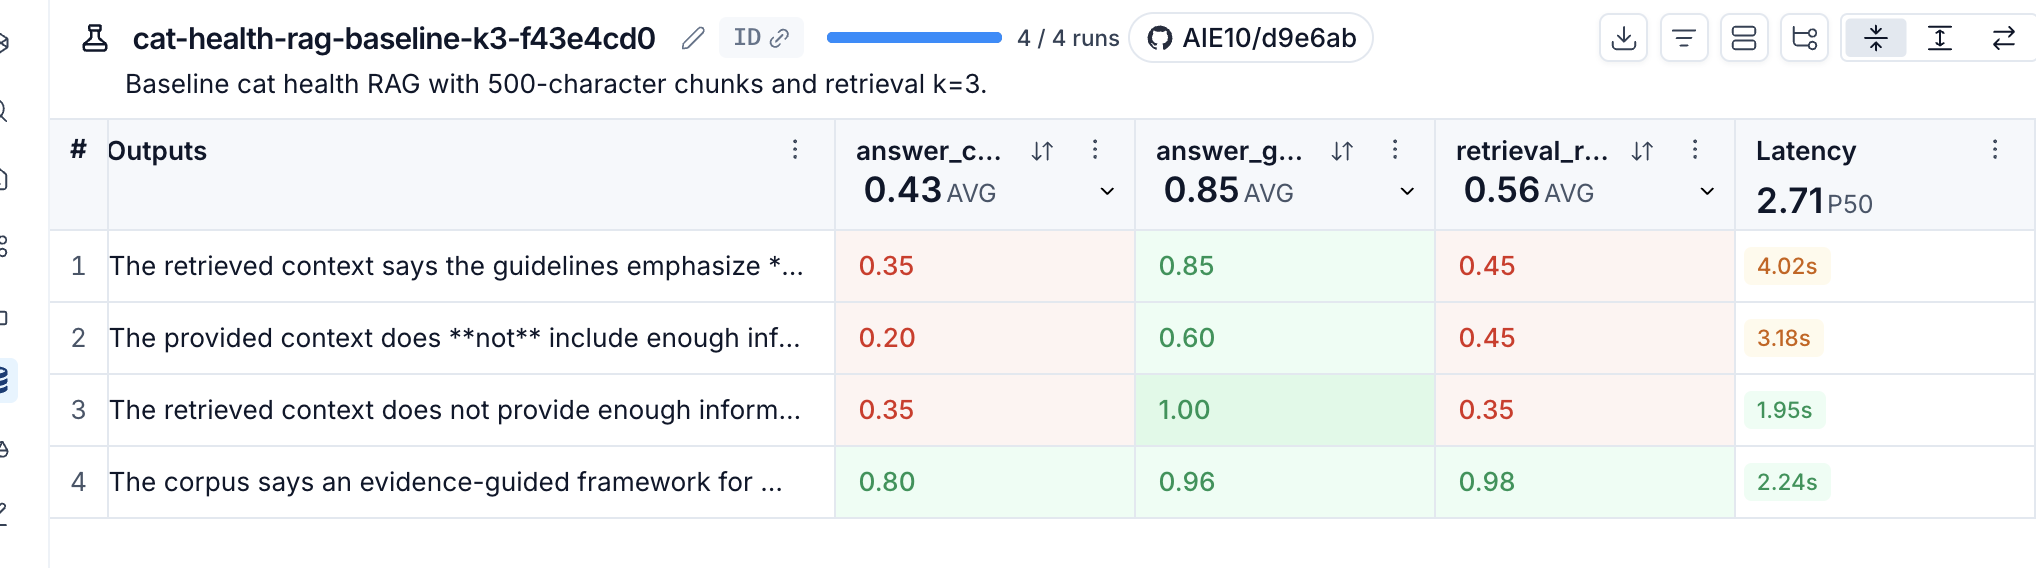
- Metric that failed: Answer correctness at 0.20, the lowest score in the entire baseline. Retrieval relevance was also low at 0.45.
- Was the synthetic reference valid? 
  Yes. The reference answer correctly names two ISFM guidelines (chronic kidney disease and diabetes mellitus) from the bibliography and connects them to the life stage framework. Both reference contexts support the answer.
- Was the retrieved context relevant and sufficient? 
  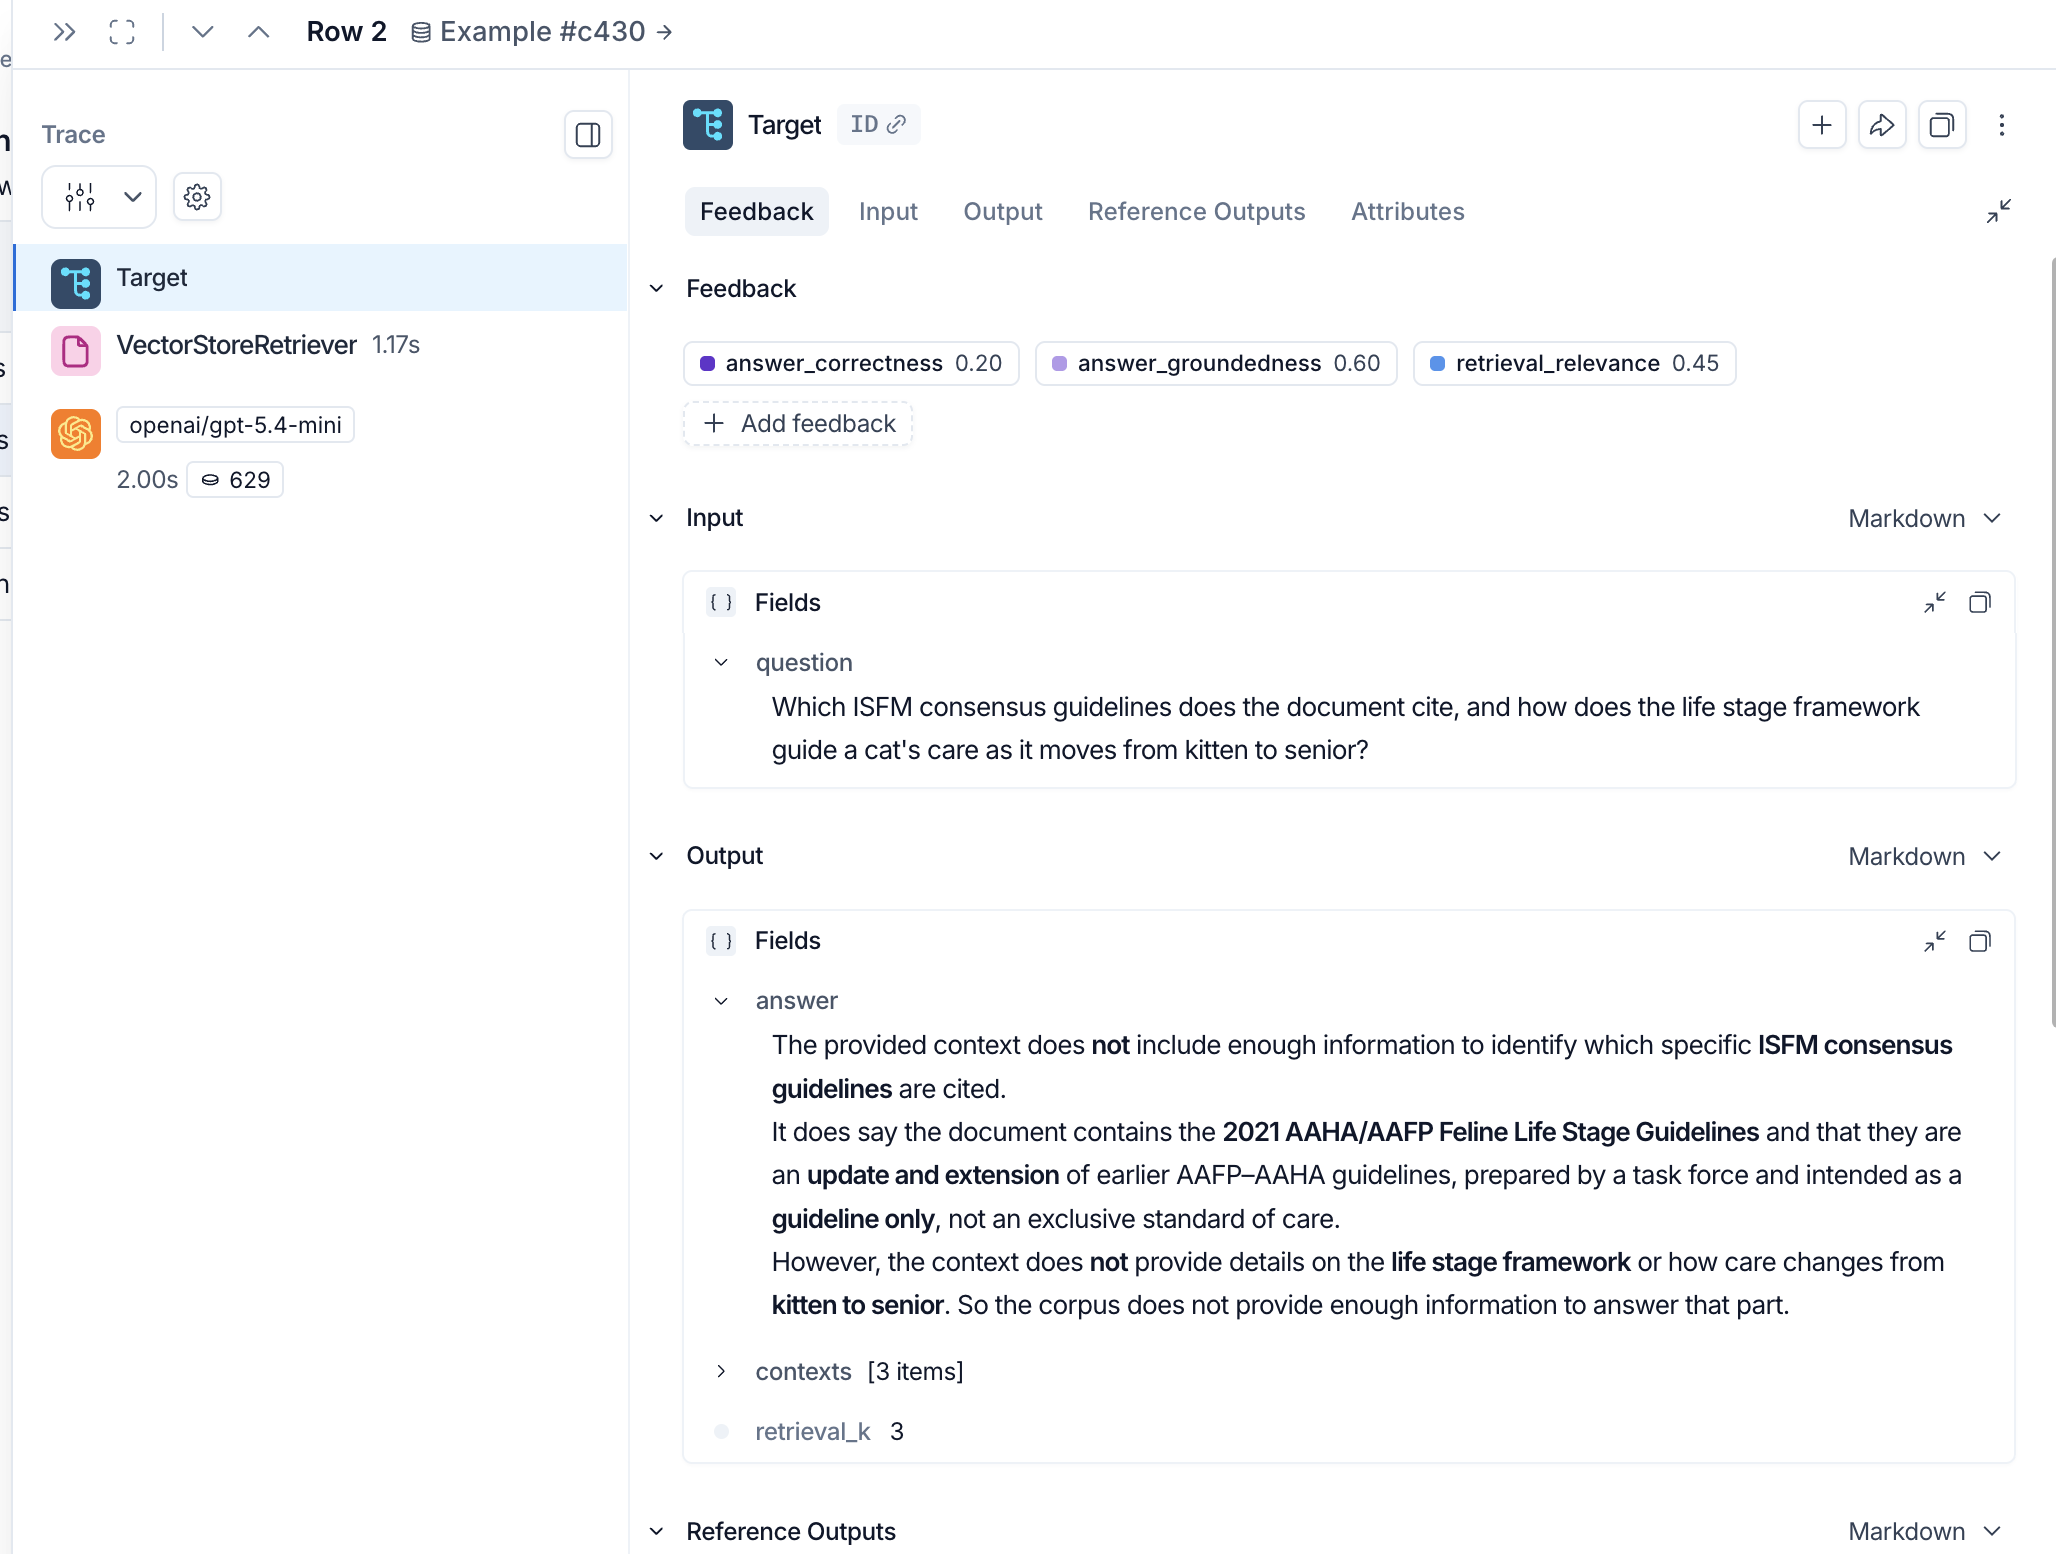
  No. All 3 retrieved chunks came from page 1 (title page and abstract), covering only authorship and publication details. The bibliography page with the ISFM citations and the life stage narrative pages were both missing. The retriever clustered on one page instead of surfacing the two different sections needed for this multi-hop question. A larger k would widen the net enough to pull in pages that ranked lower but contained the actual content needed.

  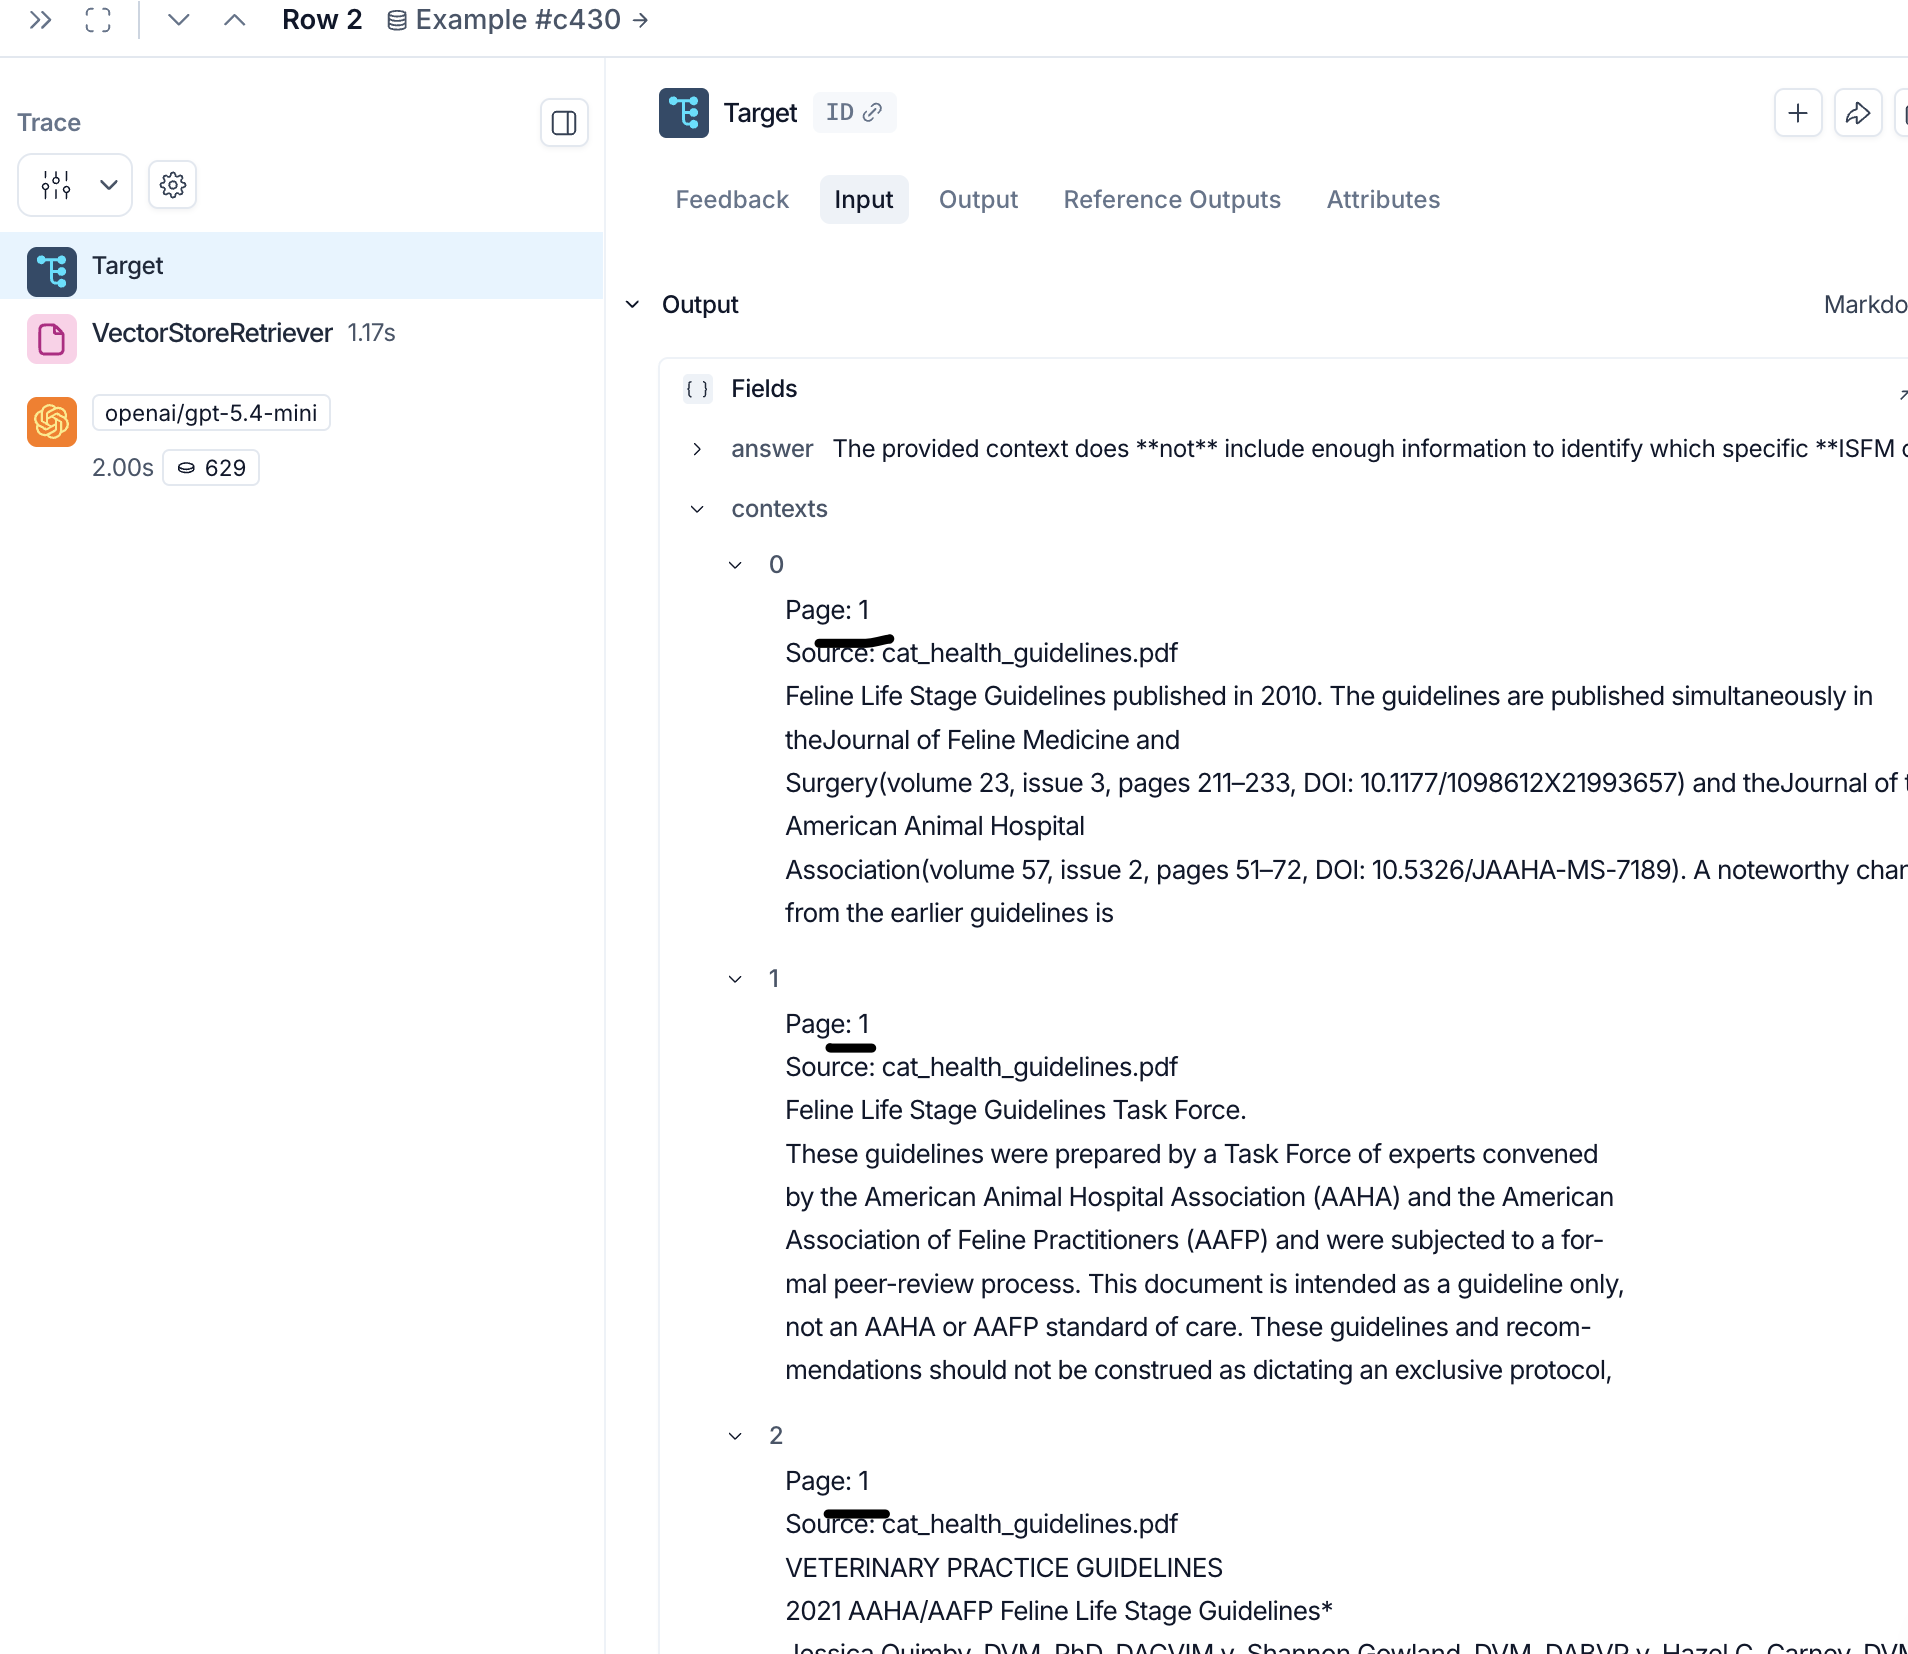
- Did the answer add unsupported information?
  No. The model correctly refused to answer beyond what the context provided, which is why groundedness was 0.60 (partial answer grounded in partial context) rather than low due to hallucination.

## Task 10: Change One Retrieval Variable and Re-Evaluate

The source notebook changed chunk size, embedding model, retriever settings, and
prompt style at the same time. That makes any score change hard to explain.

Here we change only retrieval depth:

~~~text
baseline:  k = 3
candidate: k = 6
~~~

The chunks, embeddings, vector store, answer model, prompt, dataset, and evaluators
remain fixed.

In [34]:
candidate_retrieval_k = 6
candidate_target = make_rag_target(candidate_retrieval_k)

candidate_spot_check = candidate_target(
    {"question": spot_check_question}
)

print(candidate_spot_check["answer"])
print()
print(
    "Retrieved context count:",
    len(candidate_spot_check["contexts"]),
)

The retrieved guidelines say a feline wellness visit should consider these components:

- General behavior and environment needs
- Elimination
- Nutrition and weight management
- Oral health
- Parasite control
- Vaccination
- Zoonoses and human safety
- Diagnostics

They also note related visit topics such as feline-friendly handling practices, overcoming barriers to examination visits, environmental enrichment, understanding feline behavior, practice team training, and client education.

If you want, I can also summarize how these topics are applied across a cat’s life stages using only the provided context.

Retrieved context count: 6


In [35]:
candidate_results = evaluate(
    candidate_target,
    data=dataset_name,
    evaluators=rag_evaluators,
    experiment_prefix="cat-health-rag-candidate-k6",
    description=(
        "Candidate cat health RAG with the same index and "
        "retrieval k increased from 3 to 6."
    ),
    metadata={
        "chunk_size": 500,
        "chunk_overlap": 75,
        "retrieval_k": candidate_retrieval_k,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "rag_model": RAG_MODEL_NAME,
        "judge_model": JUDGE_MODEL_NAME,
        "ai_gateway_base_url": GATEWAY_BASE_URL,
        "changed_variable": "retrieval_k",
    },
    max_concurrency=MAX_CONCURRENCY,
)

print(f"Candidate experiment: {candidate_results.experiment_name}")

View the evaluation results for experiment: 'cat-health-rag-candidate-k6-36f10a16' at:
https://eu.smith.langchain.com/o/fd4e4d03-aa8a-45ef-b33f-b83f61f694fc/datasets/3d0f7843-f56e-4f5b-947a-aff3e3eb4df7/compare?selectedSessions=7671bbee-9cf9-49cb-be87-954f0e74527e




4it [00:16,  4.00s/it]

Candidate experiment: cat-health-rag-candidate-k6-36f10a16


#### ❓ Question #6

Why is changing one variable at a time useful? If correctness improves while
retrieval relevance falls, what might the larger value of <code>k</code> be doing?

##### ✅ Answer

Changing one variable at a time is useful because it makes the results interpretable. If chunk size, embedding model, retriever settings, and prompt were all changed simultaneously, and the score went up or down, it would be hard to tell what actually helped or hurt performance. By holding everything else fixed, such as the chunks, embeddings, vector store, prompt, model, dataset, and evaluators, and only changing k from 3 to 6, any score difference is more likely caused by that one change. If correctness improves while retrieval relevance falls, the larger k may be increasing recall but lowering precision. With k=6, the retriever casts a wider net, so a relevant chunk that was ranked 4th or 5th and missed at k=3 now gets included. That can help the generator produce a more correct answer. However, the retrieval relevance judge evaluates the full set of retrieved chunks. If only 2 or 3 of the 6 chunks are actually relevant, the average relevance drops compared to a tighter k=3 set.
So the larger k is probably helping by finding the right content, but also dragging in more noise. This suggests improving retrieval precision with better embeddings, reranking, or query rewriting rather than only
  increasing k, which trades precision for recall.

## 🏗️ Activity #2: Compare, Diagnose, and Iterate

Compare the baseline and candidate experiments in LangSmith.

Requirements:

1. Record the mean score for each evaluator in both experiments.
2. Inspect at least two examples whose scores changed.
3. Decide whether <code>k=6</code> improved the application overall.
4. Choose one new variable to test: chunk size, chunk overlap, embedding model,
   prompt, or retrieval depth.
5. State your prediction before running the experiment.
6. Run a third experiment and explain the result.

Keep the reviewed dataset and evaluators fixed. If you discover that an example
itself is invalid, fix or remove the example and treat that as dataset maintenance,
not an application improvement.

In [38]:
# Activity #2 workspace
# A retrieval-depth experiment can reuse the existing vector store:

student_retrieval_k = 8
student_target = make_rag_target(student_retrieval_k)

student_results = evaluate(
    student_target,
    data=dataset_name,
    evaluators=rag_evaluators,
    experiment_prefix="cat-health-rag-candidate-k8",
    description=(
        "Third experiment: retrieval k increased from 6 to 8. "
        "Same chunks, embeddings, and vector store."
    ),
    metadata={
        "chunk_size": 500,
        "chunk_overlap": 75,
        "retrieval_k": student_retrieval_k,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "rag_model": RAG_MODEL_NAME,
        "judge_model": JUDGE_MODEL_NAME,
        "ai_gateway_base_url": GATEWAY_BASE_URL,
        "changed_variable": "retrieval_k",
    },
    max_concurrency=MAX_CONCURRENCY,
)

print(f"Student experiment: {student_results.experiment_name}")

View the evaluation results for experiment: 'cat-health-rag-candidate-k8-dae1e469' at:
https://eu.smith.langchain.com/o/fd4e4d03-aa8a-45ef-b33f-b83f61f694fc/datasets/3d0f7843-f56e-4f5b-947a-aff3e3eb4df7/compare?selectedSessions=fd34ca13-9429-4d94-89de-1e6cbe7ac21d




4it [00:19,  4.97s/it]

Student experiment: cat-health-rag-candidate-k8-dae1e469


### 📝 Activity #2 Notes

- Variable changed: Third experiment uses k=8 (Extra note: an additional experiment with k=10 was run to map the full curve).
- Prediction: Increasing k beyond 6 should continue improving correctness and retrieval relevance since more chunks means a higher chance of including relevant content. This prediction was incorrect — scores peaked at k=6 and declined at k=8 and k=10, showing that additional chunks added noise rather than useful content.
- Baseline result: (k=3) correctness 0.42, groundedness 0.85, retrieval relevance 0.56
- Candidate result: (k=6) correctness 0.68, groundedness 0.94, retrieval relevance 0.84
- Third experiment result: (k=8) correctness 0.66, groundedness 0.94, retrieval relevance 0.78
NOTE(i did one experiment extra): Additional experiment (k=10): correctness 0.60, groundedness 0.98, retrieval relevance 0.79
- NOTE: Additional experiment (k=10): correctness 0.60, groundedness 0.98, retrieval relevance 0.79
- Two traces inspected:
  - Row 1 (ISFM life stage): 

  | Experiment | Correctness | Groundedness | Retrieval Rel. |
  |---|---|---|---|
  | k=3 | 0.35 | 0.85 | 0.45 |
  | k=6 | 0.58 | 0.92 | 0.70 |
  | k=8 | 0.40 | 0.90 | 0.55 |
  | k=10 | 0.35 | 1.00 | 0.56 |

  Correctness dropped from 0.58 (k=6) to 0.40 (k=8). The model provided partial information about life stages and feline-friendly handling but correctly stated that the retrieved passages do not cover the senior-cat specifics about arthritis, resource access, and house-soiling.  Groundedness was 0.90 because the model was transparent about what was missing (Note: At k=10 the same pattern held: correctness dropped further to 0.35 with groundedness 1.00, more chunks but still not the right ones.).
  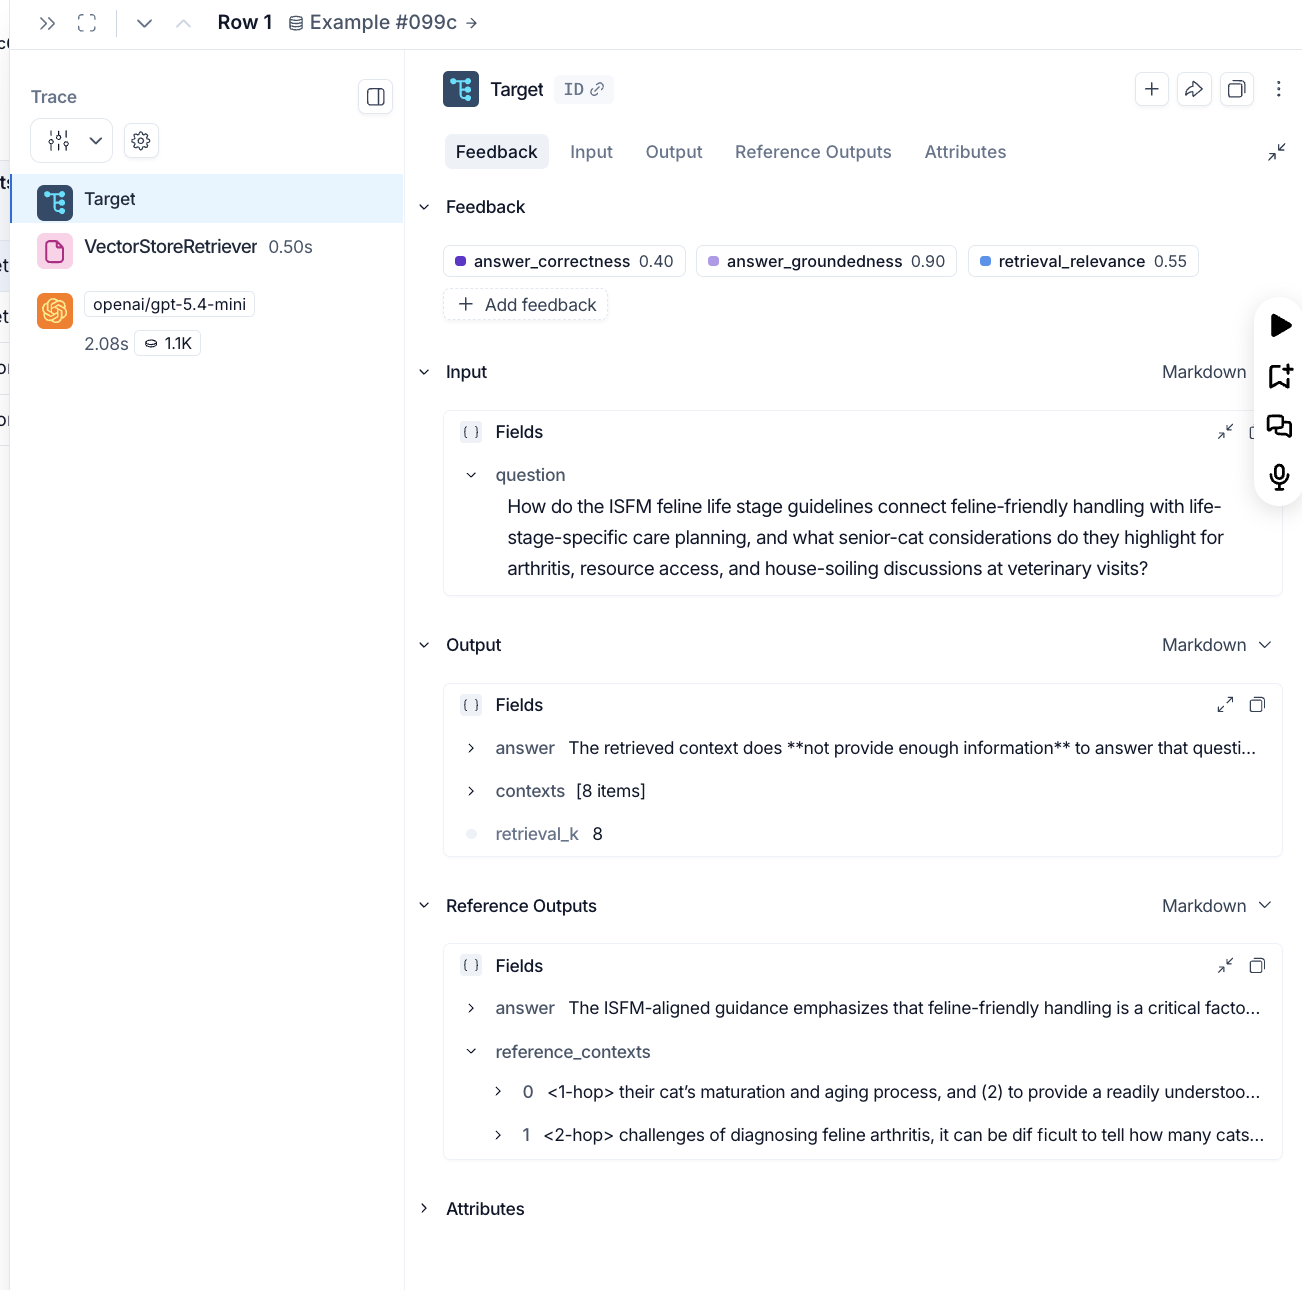
  - Row 4(cats underserved): 
    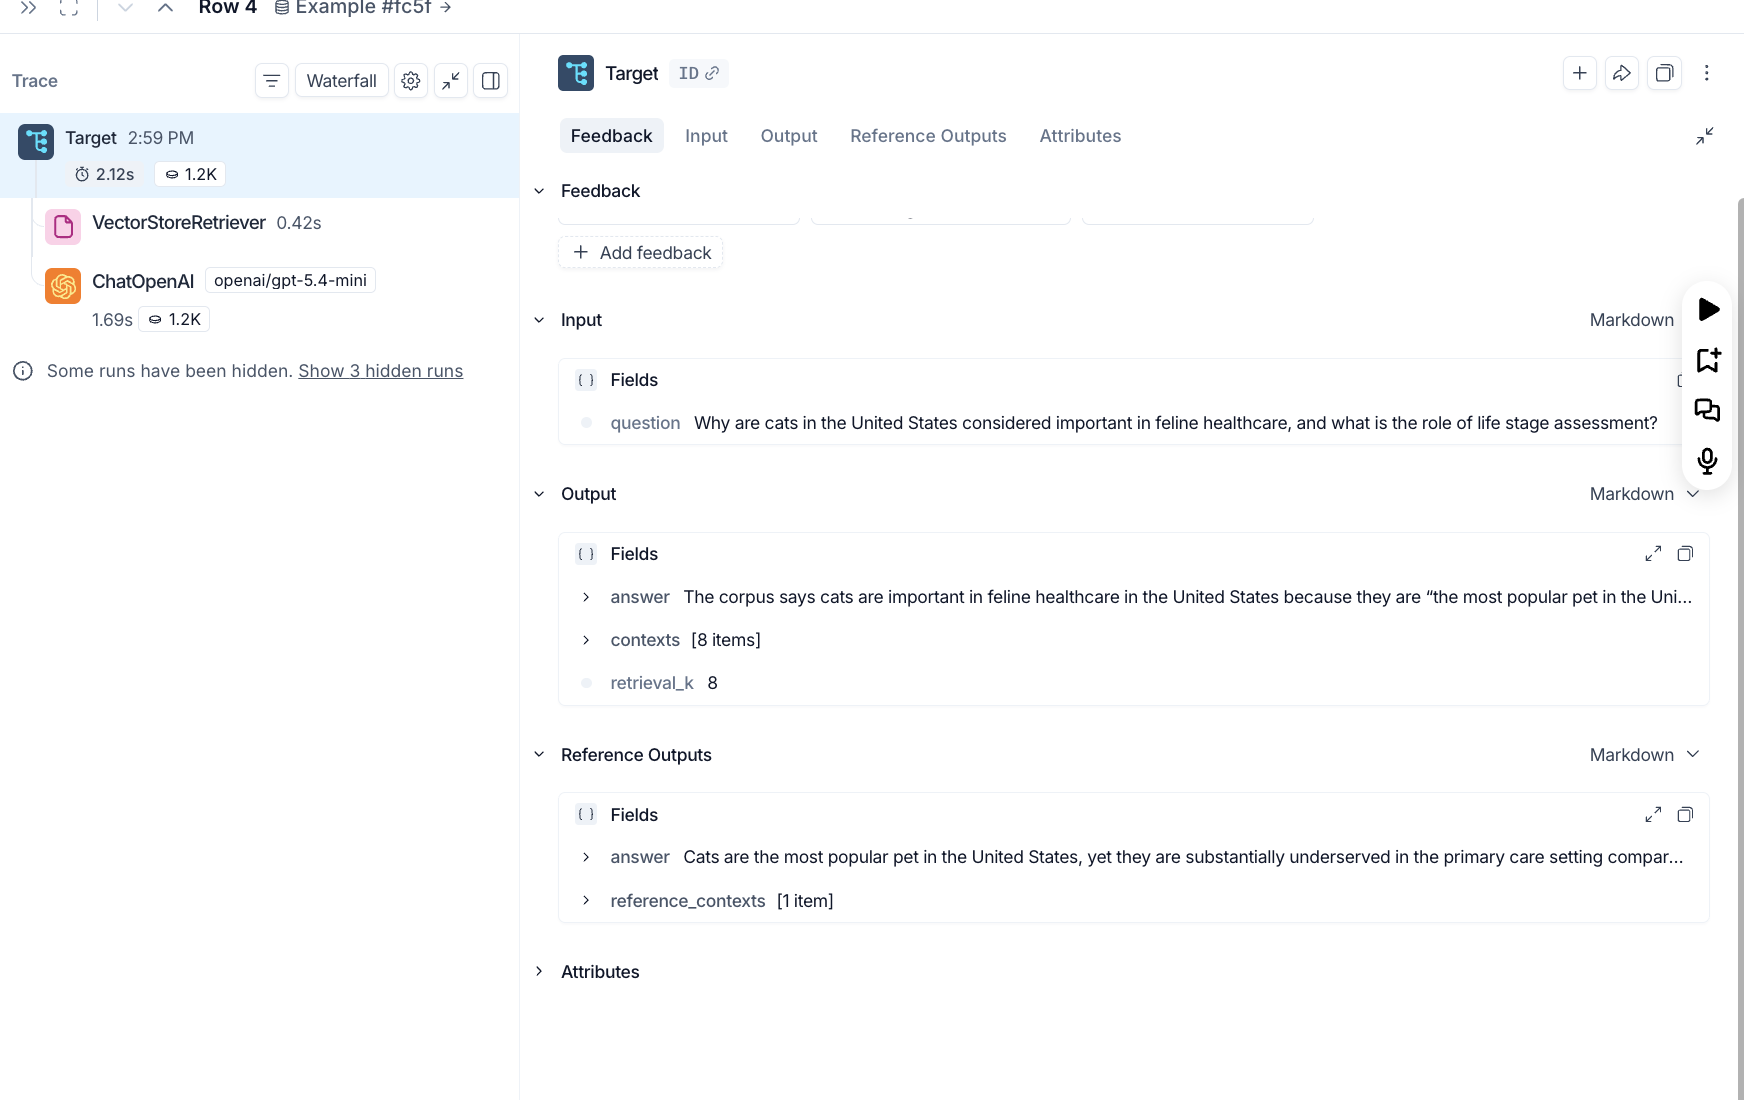

    This one is interesting because it was already the strongest example at k=3, and k=6 pushed it near perfect. 
    
    | Experiment | Correctness | Groundedness | Retrieval Rel. |
    |---|---|---|---|
    | k=3 | 0.80 | 0.96 | 0.98 |
    | k=6 | 0.95 | 0.93 | 1.00 |
    | k=8 | 0.93 | 0.98 | 0.98 |
    | k=10 | 0.82 | 1.00 | 0.98 |


    Correctness 0.93 at k=8. All 8 retrieved chunks were directly relevant to the question, explaining the high retrieval relevance (0.98) and groundedness (0.98). The answer closely matched the reference. (At k=10 correctness dropped to 0.82 while groundedness hit 1.00 — the larger context may have caused the model to produce a less focused answer.)

- Decision:  
  k=6 is the best retrieval depth for this dataset. The 4-point curve (k=3, 6, 8, 10) shows a clear peak at k=6. Below that the retriever misses relevant chunks; above it the extra chunks add noise that hurts correctness and retrieval relevance without helping the answers. The multi-hop questions (rows 1 and 2) remain the weakest regardless of k, suggesting the next improvement should target embedding quality or chunking rather than retrieval depth.
- Cost or latency tradeoff: 
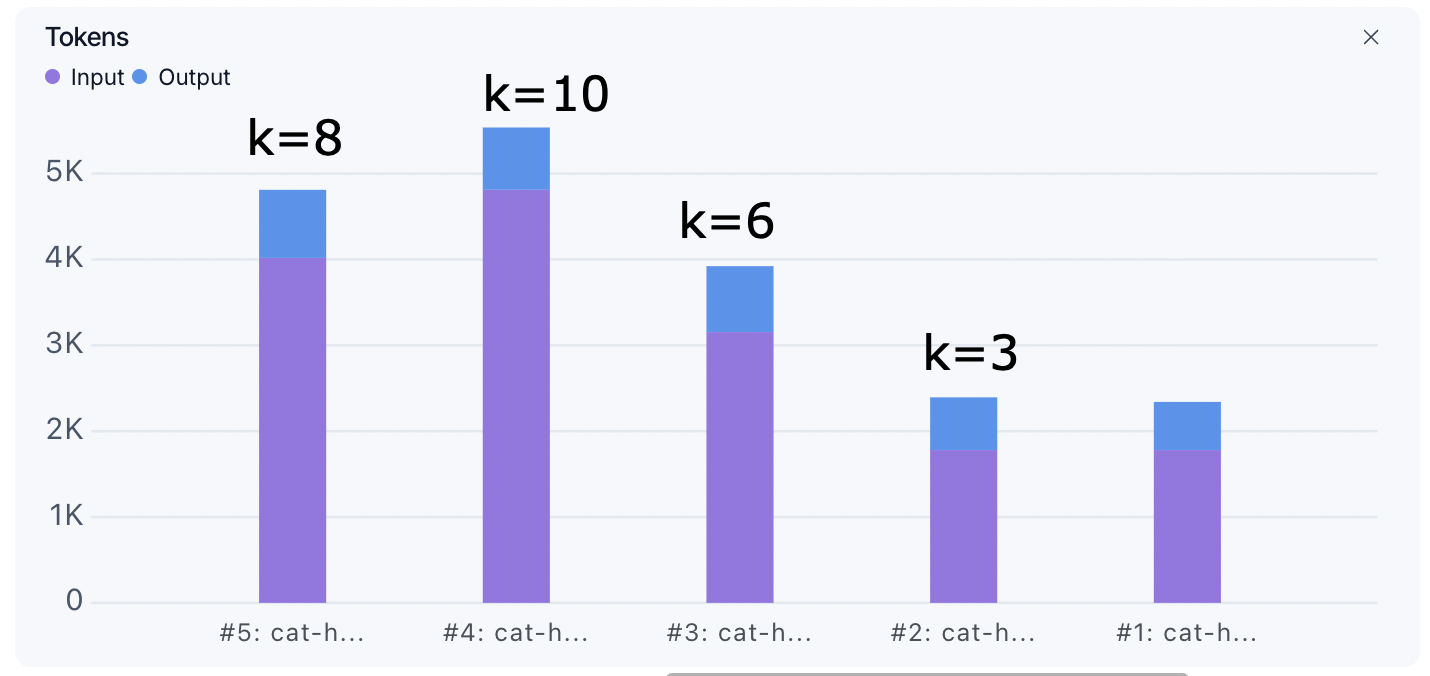
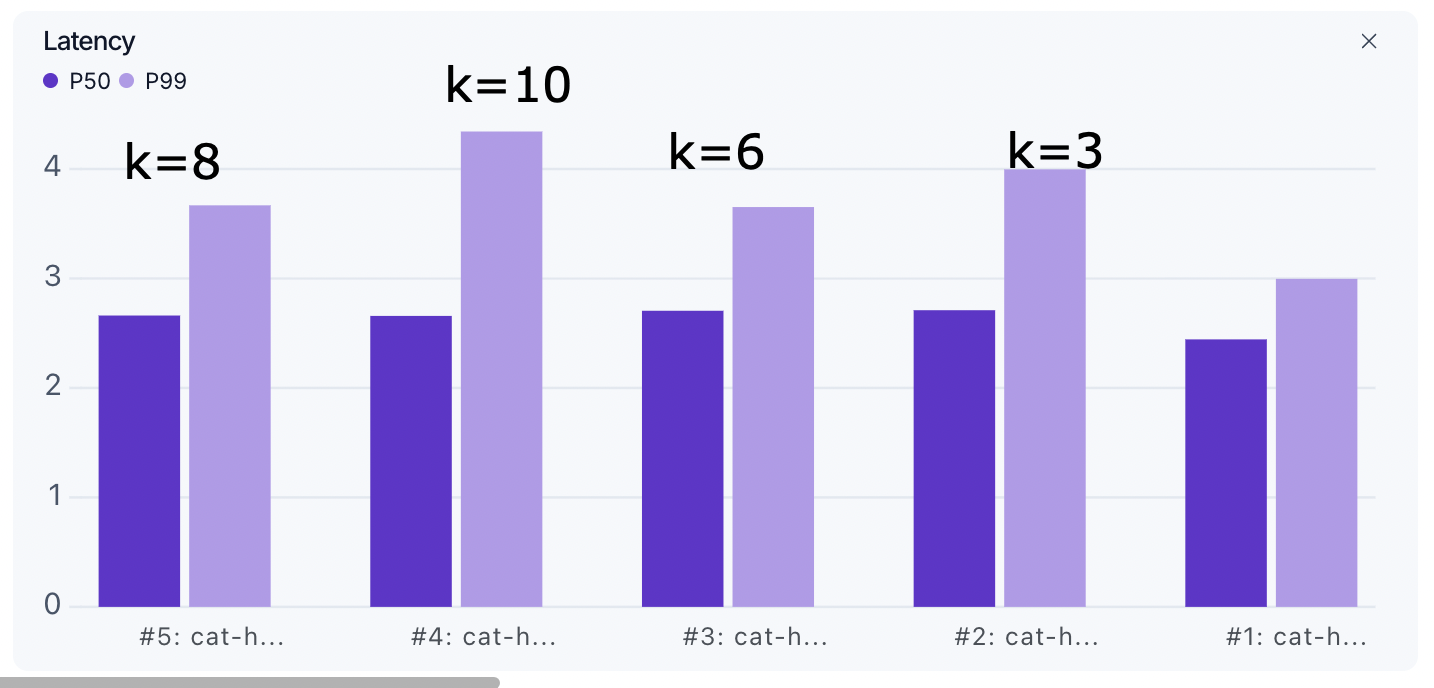
  Token usage was similar across experiments: ~4,800 (k=6), 4,811 (k=8), 5,537 (k=10). Latency was comparable at around 2.66s p50. The cost difference is marginal, so the decision is driven purely by answer quality, not budget.

## Advanced Build: Add Robustness and Adversarial Cases

Synthetic data can cover failure modes as well as happy-path questions.

Add at least three reviewed cases such as:

- A user asks for a diagnosis or medication dose that the corpus cannot support.
- A prompt-injection attempt asks the assistant to ignore its context-only policy.
- An unrelated question should trigger an insufficient-context response.
- Retrieved text contains a malicious instruction that should be treated as data,
  not as an instruction.

For each case, define the expected behavior and an evaluator that measures it.
Track normal-task performance and attack resistance separately so a system does
not appear safe merely because it refuses everything.

## Final Takeaways

- Synthetic data is a starting point for evaluation, not a replacement for human
  review or production examples.
- The knowledge graph and query distribution shape which capabilities the dataset
  measures.
- Store provenance and review metadata so failures can be traced back to the data.
- Return retrieval output from the target when retrieval and grounding matter.
- Evaluate retrieval, grounding, and answer quality separately.
- Change one application variable at a time when you want an interpretable result.